In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=1.25)

Define paths to lfs data

In [2]:
fpath_lfs = r"C:\eurostat_data"
main_data = r"Yearly Data\YearlyFiles_83_2019\_YearlyFiles"

Read geodata with NUTS regions

In [3]:
gdf = gpd.read_file(os.path.join(fpath_lfs, "felix", "NUTS_RG_03M_2021_4326_LEVL_2", "NUTS_RG_03M_2021_4326_LEVL_2.shp"))
gdf.head()

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,geometry
0,AL01,2,AL,Veri,Veri,0.0,NaN,0,AL01,"POLYGON ((19.83100 42.46645, 19.84072 42.47881..."
1,AL02,2,AL,Qender,Qender,0.0,NaN,0,AL02,"POLYGON ((20.23617 41.34849, 20.29263 41.37277..."
2,DE24,2,DE,Oberfranken,Oberfranken,0.0,NaN,0,DE24,"POLYGON ((11.48157 50.43162, 11.48290 50.40161..."
3,IE05,2,IE,Southern,Southern,0.0,NaN,0,IE05,"MULTIPOLYGON (((-7.67408 52.78129, -7.61737 52..."
4,HU11,2,HU,Budapest,Budapest,0.0,NaN,0,HU11,"POLYGON ((18.93274 47.57117, 19.02713 47.58717..."


Read preprocessed LFS data (all countries, 2019)

In [4]:
df_merged_all_vars = pd.read_csv(
    os.path.join(fpath_lfs, "felix", "eu_lfs_merged_2019.csv"),
    index_col=0
)

C:\Users\fzaussinger\Miniconda3\envs\lfs\lib\site-packages\IPython\core\interactiveshell.py:3441: DtypeWarning: Columns (6,10,24) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
C:\Users\fzaussinger\Miniconda3\envs\lfs\lib\site-packages\numpy\lib\arraysetops.py:583: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


Map of Europe

(33.0, 72.0)

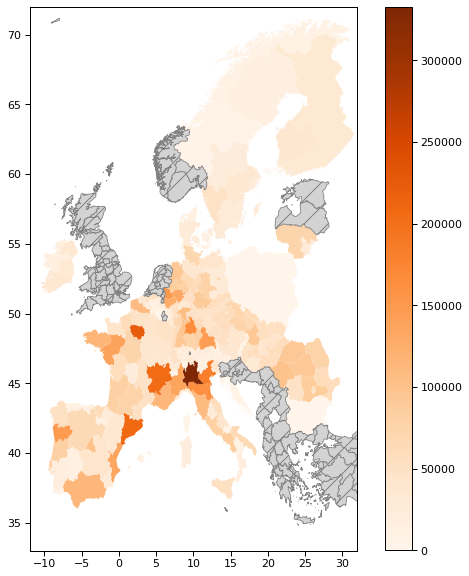

In [5]:
gdf_sub = pd.merge(
    gdf,
    df_merged_all_vars.groupby("NUTS_ID")[["COEFF", "is_green_abs", "is_brown_abs"]].sum().reset_index(),
    on="NUTS_ID",
    how="left"
)

#gdf_sub = gpd.GeoDataFrame(gdf_sub)

ax = gdf_sub.plot(column="is_brown_abs", figsize=(10, 10), legend=True, cmap="Oranges", missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"})
ax.set_xlim(-12, 32)
ax.set_ylim(33, 72)

Zoom in on Germany

In [6]:
df_de = df_merged_all_vars.loc[df_merged_all_vars.COUNTRY == "DE"]

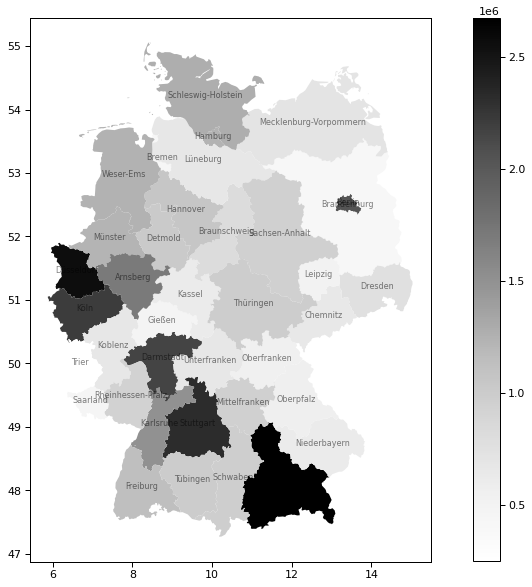

In [7]:
gdf_de = pd.merge(
    df_de.groupby("NUTS_ID").COEFF.sum().reset_index(),
    gdf,
    on="NUTS_ID",
    how="left"
)

gdf_de = gpd.GeoDataFrame(gdf_de)

ax = gdf_de.plot(column="COEFF", figsize=(15, 10), legend=True, cmap="Greys")

gdf_de.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, fontsize=8), axis=1);

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "population_de_2019.png"),
    dpi=300,
    bbox_inches="tight"
)

Earnings deciles for Germany
- Source earnings deciles (2016): https://www.bpb.de/nachschlagen/zahlen-und-fakten/soziale-situation-in-deutschland/61769/einkommensverteilung

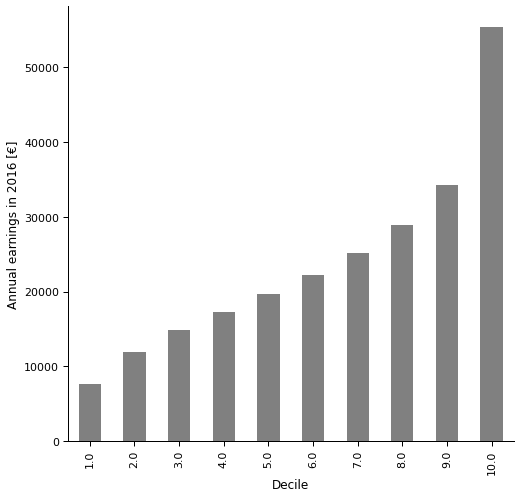

In [8]:
earnings_deciles_de = pd.read_csv(os.path.join(fpath_lfs, "felix", "earnings_distribution_germany.csv"), delimiter=";").astype(float)
earnings_deciles_de.plot.bar(x="decil", y="annual_earnings_2016", xlabel="Decile", ylabel="Annual earnings in 2016 [€]", figsize=(8,8), legend=False, color="grey")
sns.despine()

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "earnings_deciles_de_2016.png"),
    dpi=300,
    bbox_inches="tight"
)

In [9]:
df_de = pd.merge(
    df_de,
    earnings_deciles_de,
    left_on="INCDECIL",
    right_on="decil",
    how="left"
)

Export German data

In [10]:
df_de.to_csv(
    os.path.join(fpath_lfs, "felix", "eu_lfs_merged_de_2019.csv")
)

#### Estimate absolute and relative employment shares in GBN for NUTS2 regions

In [11]:
df_de_merged_by_nuts = df_de.groupby("NUTS_ID")[["COEFF", "is_brown_abs", "is_green_abs", "is_neutral_abs"]].sum()
df_de_merged_by_nuts

df_de_merged_by_nuts["is_brown_pc"] = df_de_merged_by_nuts.is_brown_abs / df_de_merged_by_nuts.COEFF
df_de_merged_by_nuts["is_neutral_pc"] = df_de_merged_by_nuts.is_neutral_abs / df_de_merged_by_nuts.COEFF
df_de_merged_by_nuts["is_green_pc"] = df_de_merged_by_nuts.is_green_abs / df_de_merged_by_nuts.COEFF

In [12]:
gdf_de_merged_by_nuts = pd.merge(
    gdf.query("CNTR_CODE == 'DE'"),
    df_de_merged_by_nuts,
    on="NUTS_ID",
    how="left"
)

#### Plot

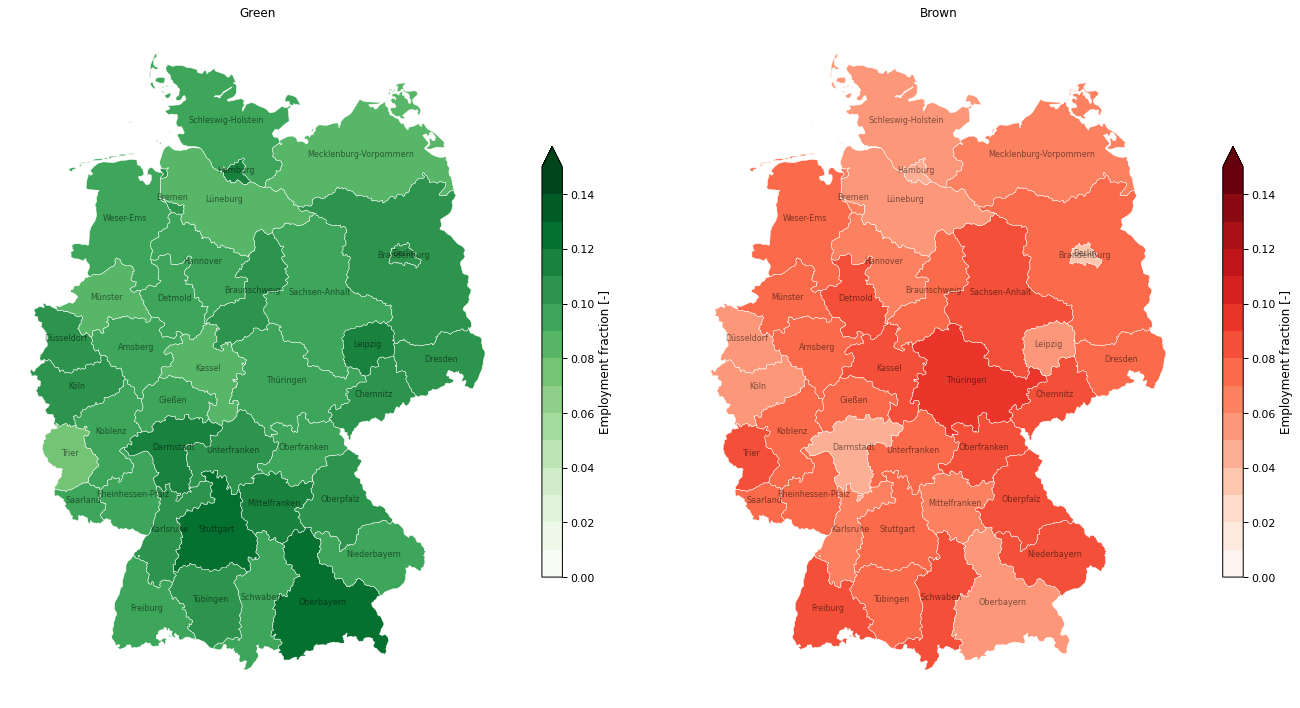

In [13]:
fig, axes = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(20, 10))

vmin, vmax = 0.0, 0.15
gdf_de_merged_by_nuts.plot(column="is_green_pc", figsize=(10, 5), legend=True, cmap=plt.get_cmap("Greens", vmax*100), vmin=vmin, vmax=vmax, ax=axes[0], legend_kwds={"label": "Employment fraction [-]", "fraction": 0.03, "extend":"max"}, edgecolor="white", linewidth=0.5)
gdf_de_merged_by_nuts.plot(column="is_brown_pc", figsize=(10, 5), legend=True, cmap=plt.get_cmap("Reds", vmax*100), vmin=vmin, vmax=vmax, ax=axes[1], legend_kwds={"label": "Employment fraction [-]", "fraction": 0.03, "extend":"max"}, edgecolor="white", linewidth=0.5)

axes[0].set_title("Green")
axes[1].set_title("Brown")

for ax in axes:
    #ax.set_xlabel("Longitude (degrees)")
    #ax.set_ylabel("Latitude (degrees)")
    ax.axis('off')
    gdf_de_merged_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

plt.tight_layout()

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "green_vs_brown_employment_de_rel.png"),
    dpi=300,
    bbox_inches="tight"
)

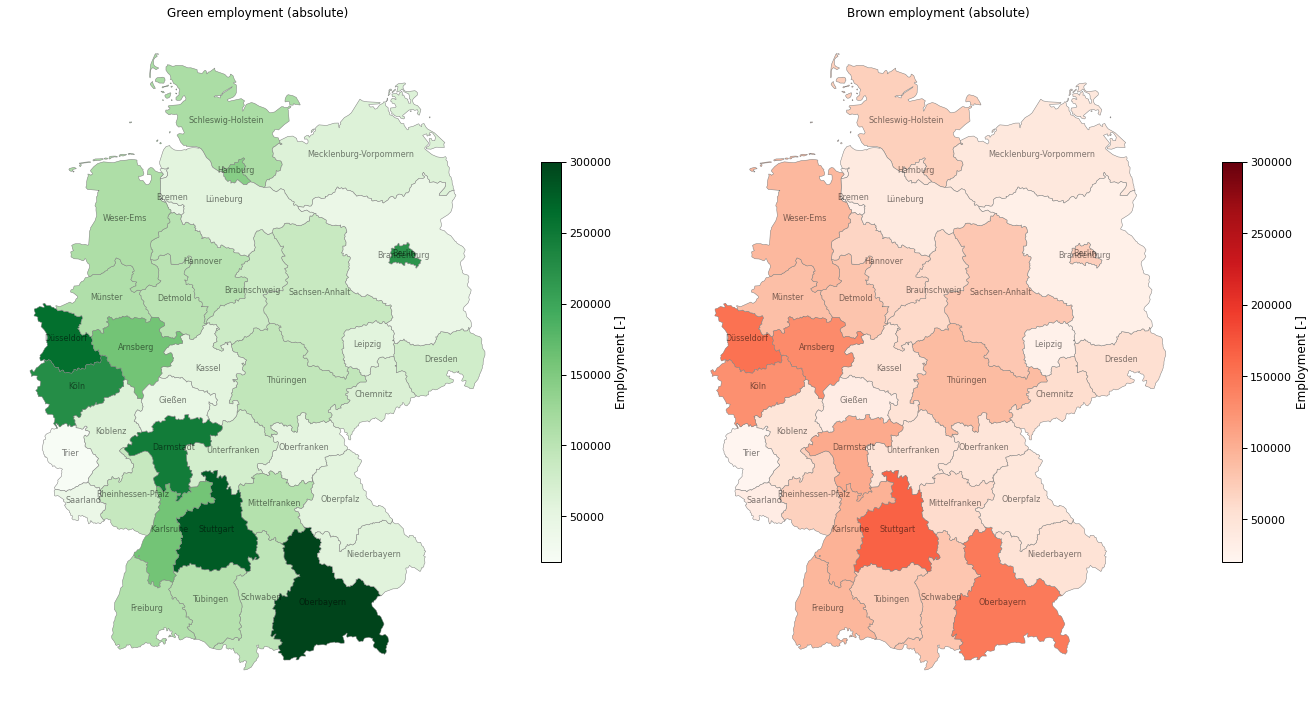

In [14]:
fig, axes = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(20, 10))

vmax = 300000
gdf_de_merged_by_nuts.plot(column="is_green_abs", figsize=(10, 5), legend=True, cmap="Greens", vmax=vmax, ax=axes[0], edgecolor="grey", linewidth=0.5, legend_kwds={"label": "Employment [-]", "fraction": 0.03})
gdf_de_merged_by_nuts.plot(column="is_brown_abs", figsize=(10, 5), legend=True, cmap="Reds", vmax=vmax, ax=axes[1], edgecolor="grey", linewidth=0.5, legend_kwds={"label": "Employment [-]", "fraction": 0.03})

axes[0].set_title("Green employment (absolute)")
axes[1].set_title("Brown employment (absolute)")

for ax in axes:
    ax.axis('off')
    gdf_de_merged_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

plt.tight_layout()

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "green_vs_brown_employment_de_abs.png"),
    dpi=300,
    bbox_inches="tight"
)

#### Look at demographic characteristics of at-risk regions

- Males more concentrated in brown occupations, but also in green occupations.
- Females mostly in neutral occupations

,is_brown,is_green,is_neutral
SEX,,,
1,0.106482,0.141037,0.752481
2,0.021915,0.061687,0.916398


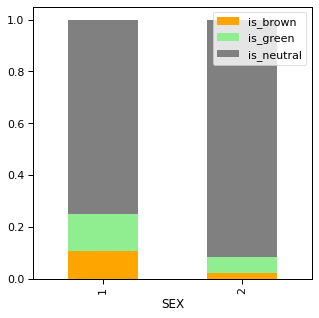

In [15]:
colors = ["orange", "lightgreen", "grey"]
df_de.groupby("SEX")[["is_brown", "is_green", "is_neutral"]].mean().plot.bar(stacked=True, figsize=(5, 5), color=colors)
df_de.groupby("SEX")[["is_brown", "is_green", "is_neutral"]].mean()

Males
- share of brown employment drops with Age 65
- share of green employment increases over age

<AxesSubplot:xlabel='SEX,AGE'>

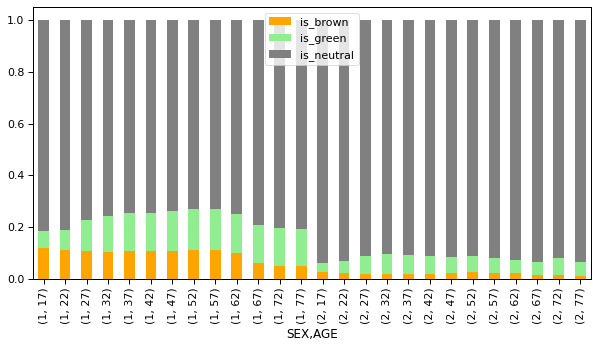

In [16]:
df_de.groupby(["SEX", "AGE"])[["is_brown", "is_green", "is_neutral"]].mean().plot.bar(stacked=True, figsize=(10,5), color=colors)

#### Skill distribution
- brown occs low to mid skilled
- green occs high skilled

<AxesSubplot:xlabel='HATLEV1D'>

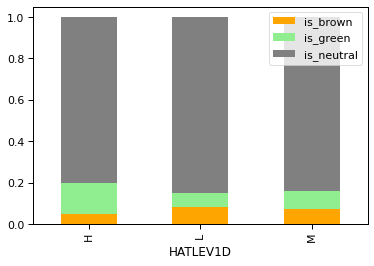

In [17]:
df_de.groupby("HATLEV1D")[["is_brown", "is_green", "is_neutral"]].mean()
df_de.groupby("HATLEV1D")[["is_brown", "is_green", "is_neutral"]].mean().plot.bar(stacked=True,  color=colors)

#### Income distribution
- share of green jobs rises towards higher incomes
- income distribution of brown jobs more bell shaped
- neutral jobs dominate low income deciles

<AxesSubplot:xlabel='INCDECIL'>

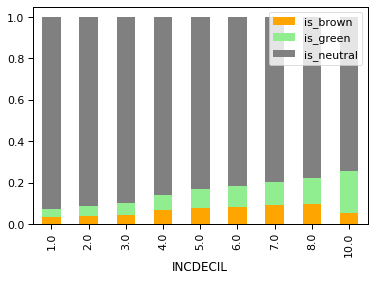

In [18]:
df_de.groupby("INCDECIL")[["is_brown", "is_green", "is_neutral"]].mean().plot.bar(stacked=True, color=colors)

#### Full vs part time
- 1: full time, 2: part time
- higher share of green part time jobs than brown part time jobs

<AxesSubplot:xlabel='FTPT'>

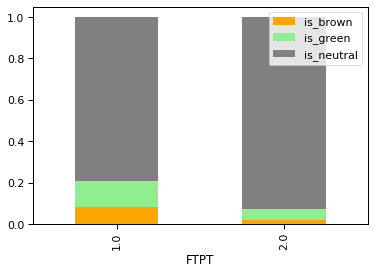

In [19]:
df_de.groupby("FTPT")[["is_brown", "is_green", "is_neutral"]].mean()
df_de.groupby("FTPT")[["is_brown", "is_green", "is_neutral"]].mean().plot.bar(stacked=True, color=colors)

#### Zoom in on coal-related ISCO 3-digit groups
- of 119 unique isco 3d groups in total 5 are related to mining
- use NACE sections to distinguish between manufacturing etc. and mining activities
- 229 observations form the basis of the analysis

#### Approach for classifying coal-related jobs based on ISCO and NACE

Relevant sectors:
- Electricity, Gas, Steam and Air Conditioning Supply
- Mining and Quarrying

Relevant ISCO groups:
- 'Manufacturing, mining, construction, and distribution managers'
- 'Mining, manufacturing and construction supervisors'
- 'Mining and mineral processing plant operators'
- 'Labourers in mining, construction, manufacturing and transport'
- 'Mining and construction labourers'

In [20]:
df_de_merged_mining = df_de.loc[df_de.mining == True]

Distribution of employees in mining-related occupation groups by industry sector

In [21]:
df_de_merged_mining.groupby(["NACE1D_label"]).COEFF.sum()

NACE1D_label
Electricity, Gas, Steam and Air Conditioning Supply    21322.01
Mining and Quarrying                                   13402.41
Name: COEFF, dtype: float64

A total of approximately 35000 mining related jobs

In [22]:
df_de_merged_mining.groupby(["NACE1D_label", "ISCO3D_label"]).COEFF.sum()

NACE1D_label                                         ISCO3D_label                                                  
Electricity, Gas, Steam and Air Conditioning Supply  Manufacturing, mining, construction, and distribution managers     5051.6600
                                                     Mining and construction labourers                                   174.1250
                                                     Mining and mineral processing plant operators                       858.6200
                                                     Mining, manufacturing and construction supervisors                15237.6050
Mining and Quarrying                                 Manufacturing, mining, construction, and distribution managers     1320.8100
                                                     Mining and construction labourers                                   821.6550
                                                     Mining and mineral processing plant operators      

In [23]:
dict(zip(df_de_merged_mining.ISCO3D_label.unique(), df_de_merged_mining.ISCO3D.unique()))

{'Mining, manufacturing and construction supervisors': 312,
 'Mining and mineral processing plant operators': 811,
 'Manufacturing, mining, construction, and distribution managers': 132,
 'Mining and construction labourers': 931}

### Spatial distribution of mining jobs

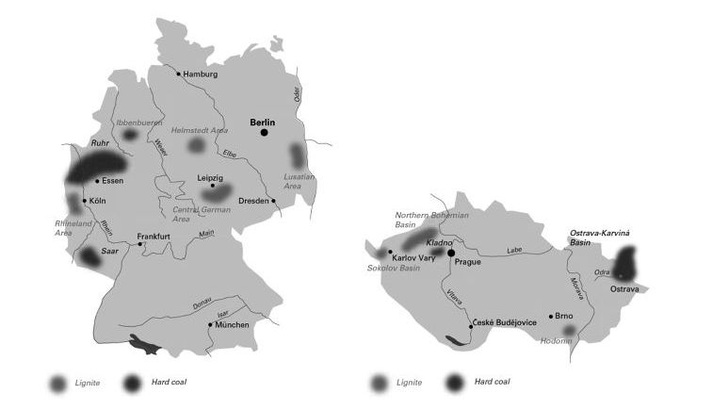

#### By sector

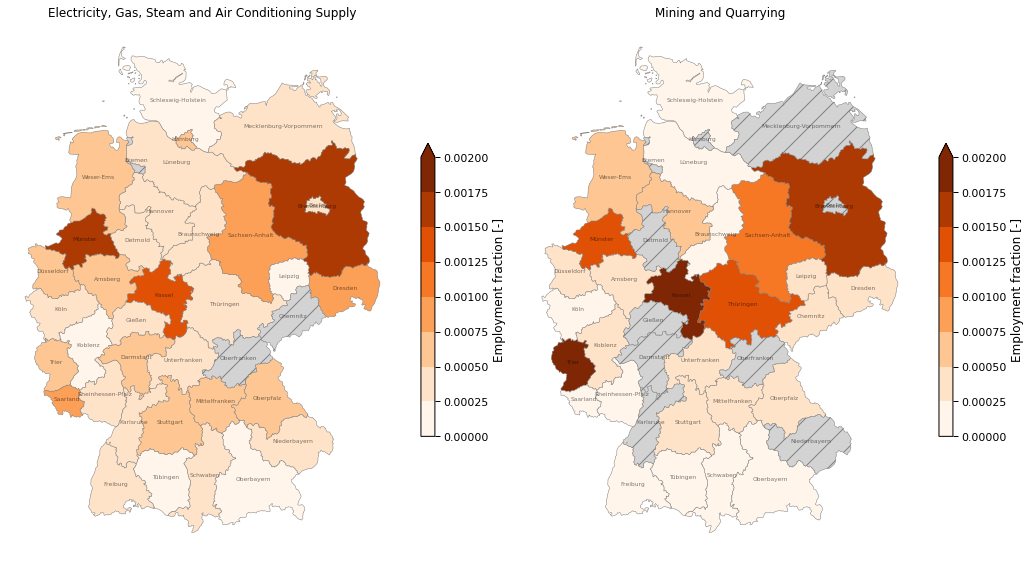

In [24]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()
vmin, vmax = 0, 0.002

for i, nace_group in enumerate(df_de_merged_mining.NACE1D_label.unique()):
    subset = df_de_merged_mining.loc[df_de_merged_mining.NACE1D_label == nace_group]

    subset_by_nuts = subset.groupby("NUTS_ID")[["COEFF", "is_brown_abs", "is_green_abs", "is_neutral_abs"]].sum()
    subset_by_nuts["COEFF_mining_pc"] = subset_by_nuts.COEFF / df_de_merged_by_nuts.COEFF
    
    gdf_subset_by_nuts = pd.merge(
        gdf.query("CNTR_CODE == 'DE'"),
        subset_by_nuts,
        on="NUTS_ID",
        how="left"
    )
    
    ax = axes[i]
    gdf_subset_by_nuts.plot(column="COEFF_mining_pc", legend=True, cmap=plt.get_cmap("Oranges", 8), ax = ax, vmin=vmin, legend_kwds={"label": "Employment fraction [-]", "fraction": 0.03, "extend": "max"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, vmax=vmax, edgecolor="grey", linewidth=0.5)
    gdf_subset_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=6), axis=1)
    ax.set_title(nace_group) 
    
    ax.axis('off')
    
plt.tight_layout()

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "coal_employment_rel_by_sector_de_2019.png"),
    dpi=300,
    bbox_inches="tight"
)

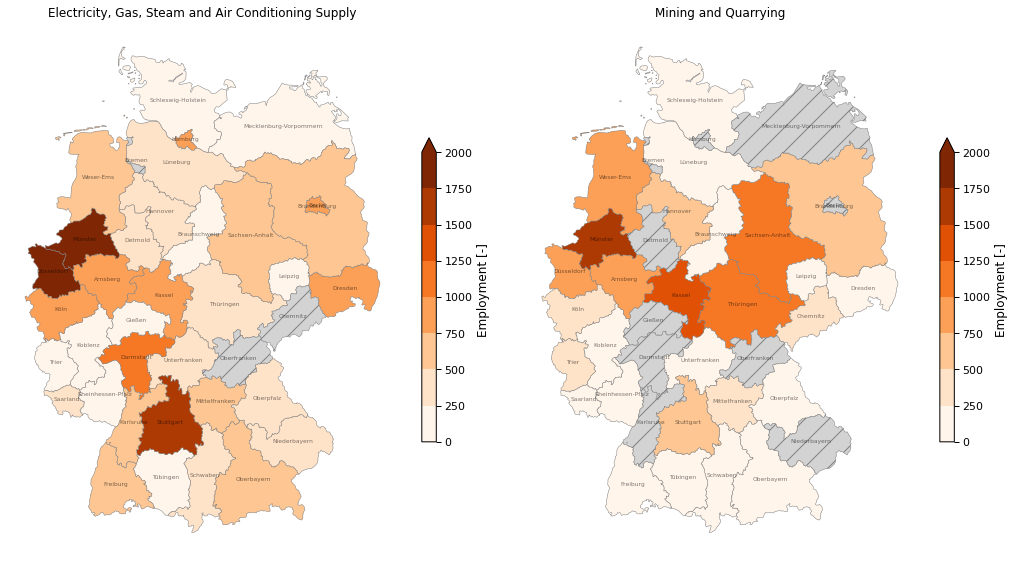

In [25]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, nace_group in enumerate(df_de_merged_mining.NACE1D_label.unique()):
    subset = df_de_merged_mining.loc[df_de_merged_mining.NACE1D_label == nace_group]

    subset_by_nuts = subset.groupby("NUTS_ID")[["COEFF", "is_brown_abs", "is_green_abs", "is_neutral_abs"]].sum()
    #subset_by_nuts["COEFF_mining_pc"] = subset_by_nuts.COEFF / df_de_merged_by_nuts.COEFF
    
    gdf_subset_by_nuts = pd.merge(
        gdf.query("CNTR_CODE == 'DE'"),
        subset_by_nuts,
        on="NUTS_ID",
        how="left"
    )

    ax = axes[i]
    gdf_subset_by_nuts.plot(column="COEFF", legend=True, cmap=plt.get_cmap("Oranges", 8), ax = ax, vmin=0, legend_kwds={"label": "Employment [-]", "fraction": 0.03, "extend": "max"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, vmax=2000, edgecolor="grey", linewidth=0.5)
    gdf_subset_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=6), axis=1)

    ax.set_title(nace_group) 
    
    ax.axis('off')
    
plt.tight_layout()

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "coal_employment_abs_by_sector_de_2019.png"),
    dpi=300,
    bbox_inches="tight"
)

#### By occupation

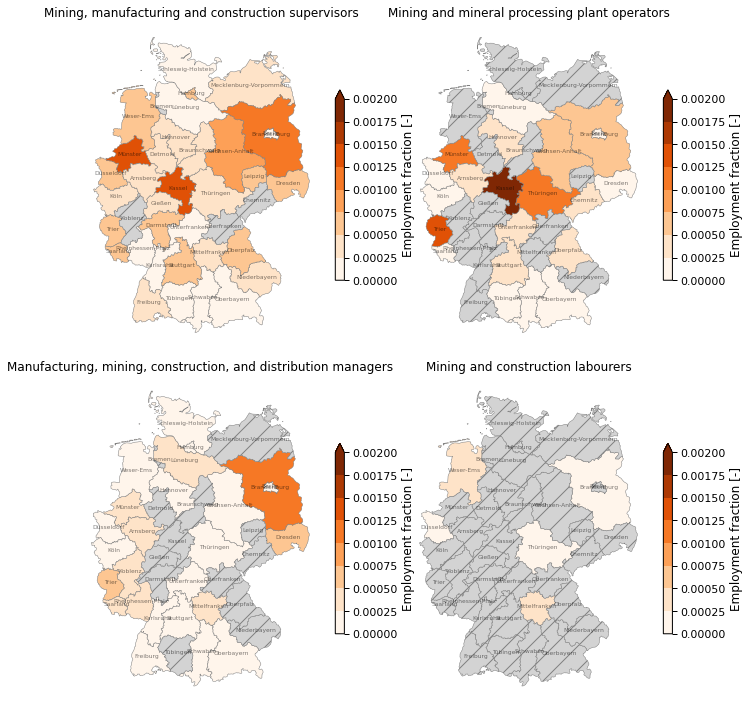

In [26]:
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(10, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, group in enumerate(df_de_merged_mining.ISCO3D_label.unique()):
    subset = df_de_merged_mining.loc[df_de_merged_mining.ISCO3D_label == group]

    subset_by_nuts = subset.groupby("NUTS_ID")[["COEFF", "is_brown_abs", "is_green_abs", "is_neutral_abs"]].sum()
    subset_by_nuts["COEFF_mining_pc"] = subset_by_nuts.COEFF / df_de_merged_by_nuts.COEFF
    
    gdf_subset_by_nuts = pd.merge(
        gdf.query("CNTR_CODE == 'DE'"),
        subset_by_nuts,
        on="NUTS_ID",
        how="left"
    )

    ax = axes[i]
    gdf_subset_by_nuts.plot(column="COEFF_mining_pc", legend=True, cmap=plt.get_cmap("Oranges", 8), ax = ax, vmin=0, legend_kwds={"label": "Employment fraction [-]", "fraction": 0.03, "extend":"max"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, vmax=0.002, edgecolor="grey", linewidth=0.5)
    gdf_subset_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=6), axis=1)
    ax.set_title(group) 
    
    ax.axis('off')
    
plt.tight_layout()

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "coal_employment_rel_by_occupation_de_2019.png"),
    dpi=300,
    bbox_inches="tight"
)

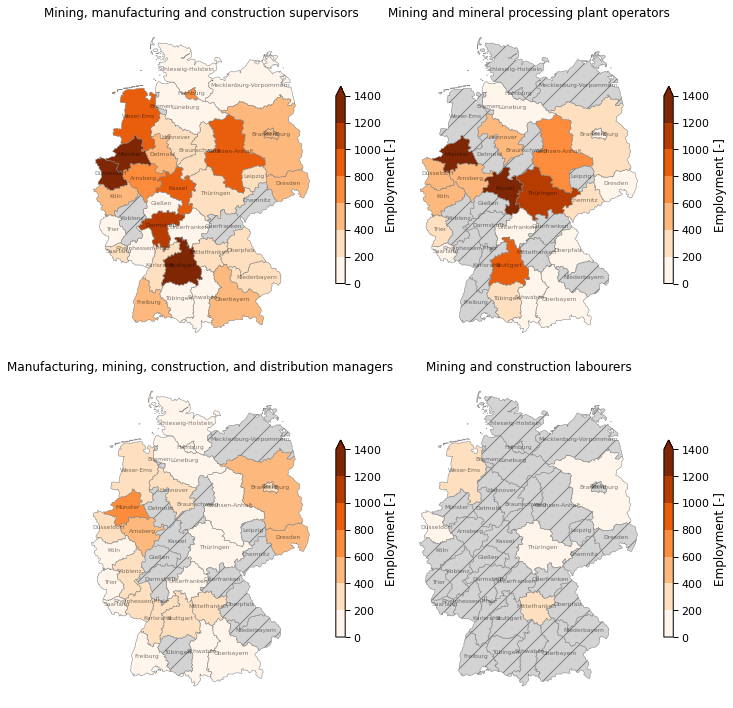

In [27]:
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(10, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, group in enumerate(df_de_merged_mining.ISCO3D_label.unique()):
    subset = df_de_merged_mining.loc[df_de_merged_mining.ISCO3D_label == group]

    subset_by_nuts = subset.groupby("NUTS_ID")[["COEFF", "is_brown_abs", "is_green_abs", "is_neutral_abs"]].sum()
    subset_by_nuts["COEFF_mining_pc"] = subset_by_nuts.COEFF / df_de_merged_by_nuts.COEFF
    
    gdf_subset_by_nuts = pd.merge(
        gdf.query("CNTR_CODE == 'DE'"),
        subset_by_nuts,
        on="NUTS_ID",
        how="left"
    )

    ax = axes[i]
    gdf_subset_by_nuts.plot(column="COEFF", legend=True, cmap=plt.get_cmap("Oranges", 7), ax = ax, vmin=0, legend_kwds={"label": "Employment [-]", "fraction": 0.03, "extend":"max"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5, vmax=1400)
    gdf_subset_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=6), axis=1)
    ax.set_title(group) 
    
    ax.axis('off')
    
plt.tight_layout()

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "coal_employment_abs_by_occupation_de_2019.png"),
    dpi=300,
    bbox_inches="tight"
)

#### Combined

In [28]:
df_de_merged_mining_by_nuts = df_de_merged_mining.groupby("NUTS_ID")[["COEFF", "is_brown_abs", "is_green_abs", "is_neutral_abs"]].sum()
df_de_merged_mining_by_nuts["COEFF_mining_pc"] = df_de_merged_mining_by_nuts.COEFF / df_de_merged_by_nuts.COEFF

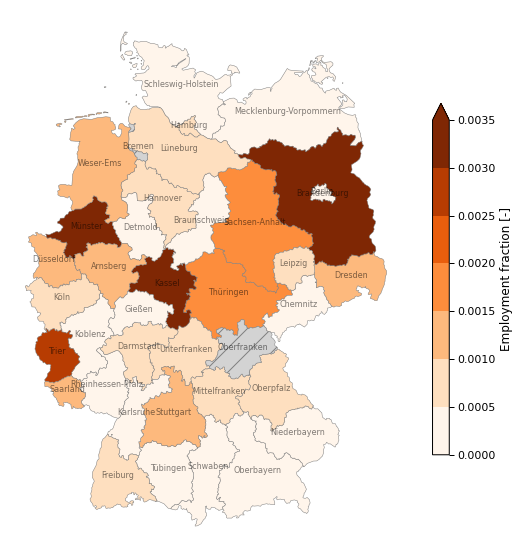

In [29]:
gdf_de_merged_mining_by_nuts = pd.merge(
    gdf.query("CNTR_CODE == 'DE'"),
    df_de_merged_mining_by_nuts,
    on="NUTS_ID",
    how="left"
)


ax = gdf_de_merged_mining_by_nuts.plot(column="COEFF_mining_pc", figsize=(10, 10), legend=True, cmap=plt.get_cmap("Oranges", 7), vmin=0, legend_kwds={"label": "Employment fraction [-]", "fraction": 0.03, "extend": "max"}, vmax=0.0035, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_de_merged_mining_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

ax.axis('off')

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "coal_employment_rel_de_2019.png"),
    dpi=300,
    bbox_inches="tight"
)

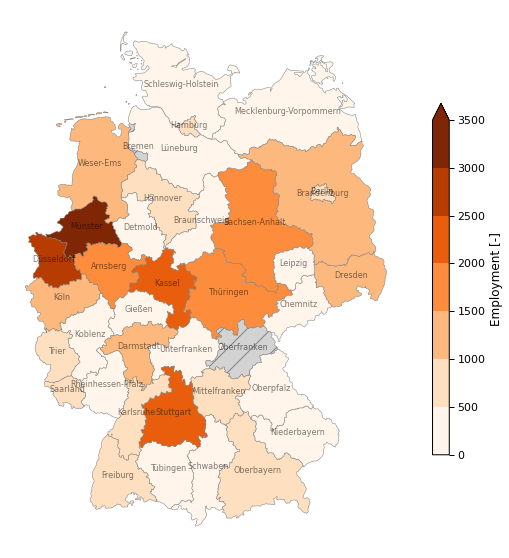

In [30]:
gdf_de_merged_mining_by_nuts = pd.merge(
    gdf.query("CNTR_CODE == 'DE'"),
    df_de_merged_mining_by_nuts,
    on="NUTS_ID",
    how="left"
)


ax = gdf_de_merged_mining_by_nuts.plot(column="COEFF", figsize=(10, 10), legend=True, cmap=plt.get_cmap("Oranges", 7), vmin=0, vmax=3500, legend_kwds={"label": "Employment [-]", "fraction": 0.03, "extend":"max"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_de_merged_mining_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

ax.axis('off')

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "coal_employment_abs_de_2019.png"),
    dpi=300,
    bbox_inches="tight"
)

#### Demographic characteristics of mining-related jobs

Mining occupation older on average

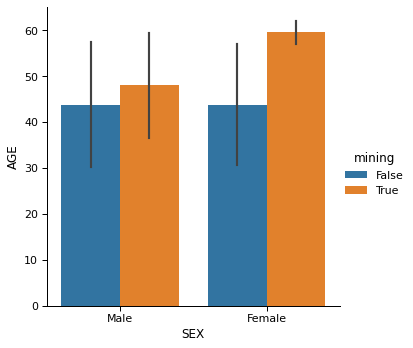

In [31]:
g = sns.catplot(
    x="SEX",
    y="AGE",
    hue="mining",
    kind="bar",
    ci="sd",
    data=df_de
)

g.set_xticklabels(["Male", "Female"])

34724.42

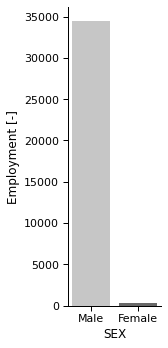

In [32]:
g = sns.catplot(
    x="SEX",
    y="COEFF",
    kind="bar",
    estimator=np.sum,
    ci=None,
    data=df_de[df_de.mining],
    palette="Greys",
    height=5,
    aspect=0.5
)

g.set_xticklabels(["Male", "Female"])
g.axes[0][0].set_ylabel("Employment [-]")

df_de[df_de.mining].groupby("SEX").COEFF.sum() / df_de[df_de.mining].groupby("SEX").COEFF.sum().sum()
df_de[df_de.mining].groupby("SEX").COEFF.sum().sum()

Mining occupations seem to earn higher wages across all skill levels (8ung: earnings are self-reported!!)

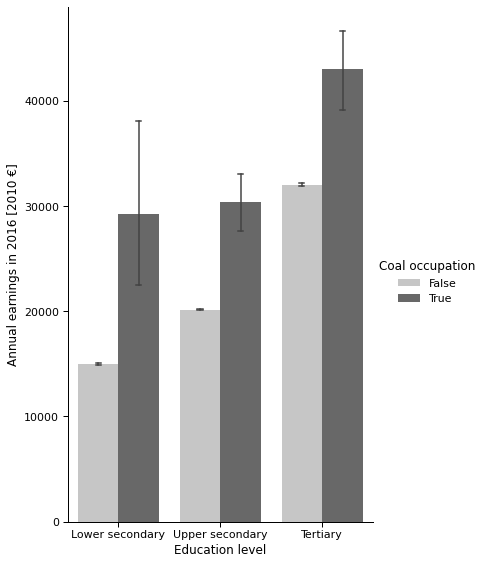

In [33]:
g = sns.catplot(
    x="HATLEV1D",
    y="annual_earnings_2016",  # annual_earnings_2016
    hue="Coal occupation",
    kind="bar",
    ci=95,
    order=["L", "M", "H"],
    data=df_de.rename(columns={"mining": "Coal occupation"}),
    height=8,
    aspect=0.7,
    palette="Greys",
    errwidth=1.5,
    capsize=0.05
)

g.set_xticklabels(["Lower secondary", "Upper secondary", "Tertiary"])
g.axes[0][0].set_ylabel("Annual earnings in 2016 [2010 €]")
g.axes[0][0].set_xlabel("Education level")

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "demographics_earnings_education_de_2019.png"),
    dpi=300,
    bbox_inches="tight"
)

In [34]:
df_de.groupby("mining")["HATLEV1D"].value_counts()

mining  HATLEV1D
False   M           150040
        H            78233
        L            31009
True    H              115
        M               99
        L               14
Name: HATLEV1D, dtype: int64

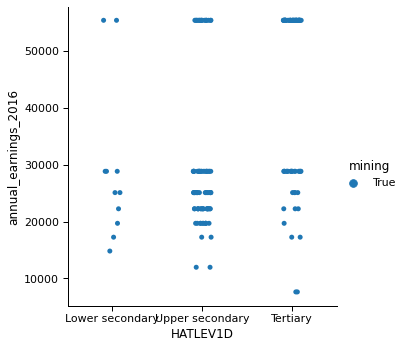

In [35]:
g = sns.catplot(
    x="HATLEV1D",
    y="annual_earnings_2016",  # annual_earnings_2016
    hue="mining",
    kind="strip",
    ci="sd",
    order=["L", "M", "H"],
    data=df_de[df_de.mining]
)

g.set_xticklabels(["Lower secondary", "Upper secondary", "Tertiary"])

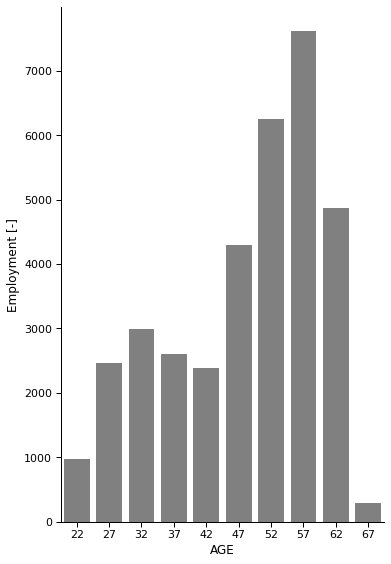

In [36]:
g = sns.catplot(
    x="AGE",
    y="COEFF",
    color="grey",
    kind="bar",
    estimator=np.sum,
    ci=None,
    data=df_de[df_de.mining],
    height=8,
    aspect=0.7
)

g.axes[0][0].set_ylabel("Employment [-]")

plt.tight_layout()

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "demographics_age_distribution_de_2019.png"),
    dpi=300,
    bbox_inches="tight"
)

In [37]:
df_de[df_de.mining].AGE.median()

52.0

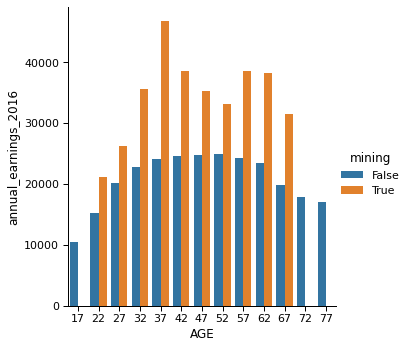

In [38]:
g = sns.catplot(
    x="AGE",
    y="annual_earnings_2016",
    hue="mining",
    kind="bar",
    #estimator=np.mean,
    ci=None,
    data=df_de
)

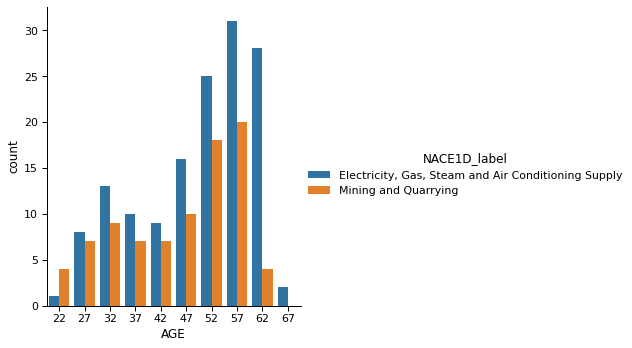

In [39]:
g = sns.catplot(
    x="AGE",
    hue="NACE1D_label",
    kind="count",
    #estimator=np.mean,
    ci=None,
    data=df_de_merged_mining
)